In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

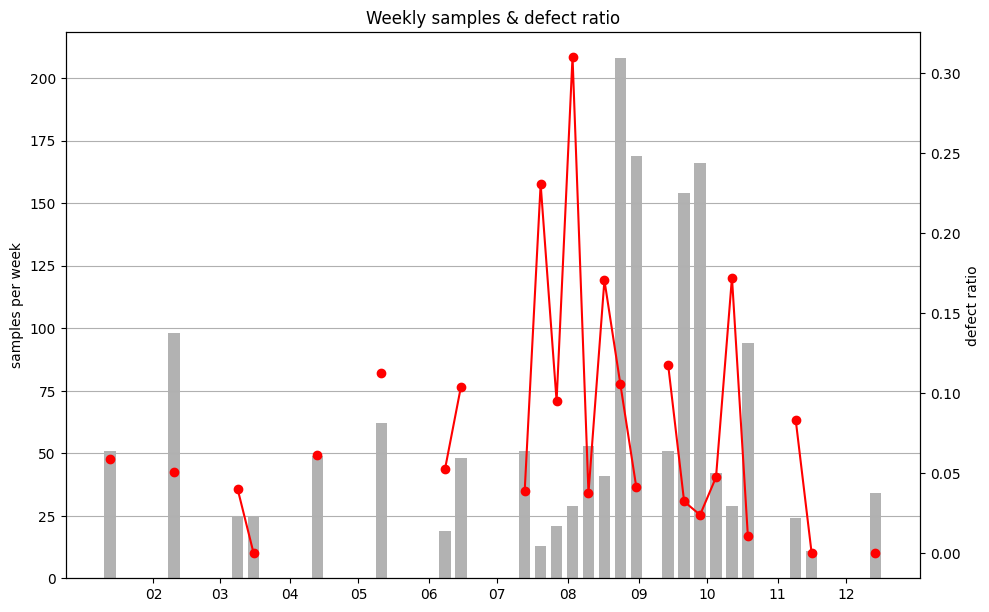

In [2]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


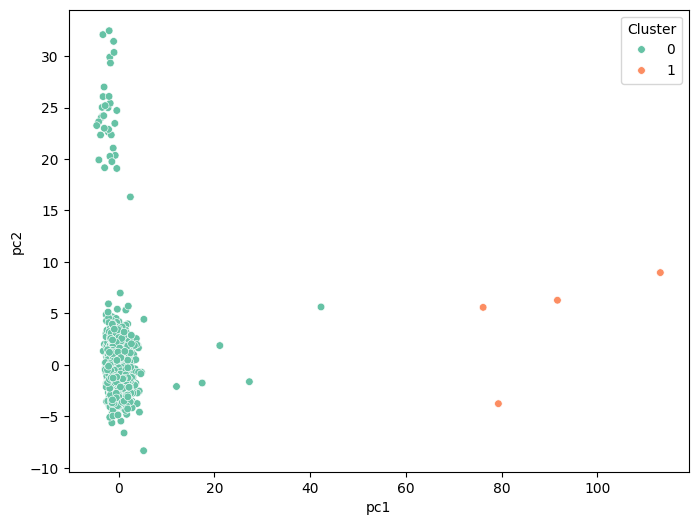

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 133 個主成分
cluster sizes: {0: 948, 1: 1197}
cluster    0    1
y                
0        743  687
1        205  510


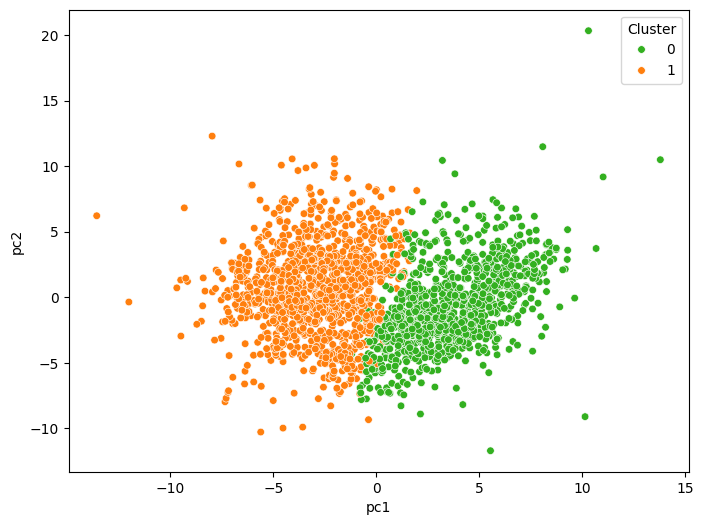

In [4]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette=palette)
plt.show()


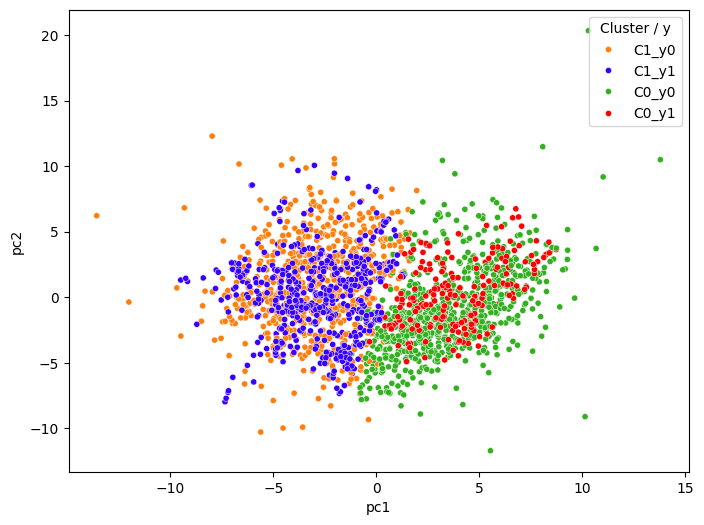

In [5]:
X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['Cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#33B020",  # cluster 0, y=0
    'C0_y1': "#ff0000",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

In [6]:
# 1. 各群 y 分布
ct = pd.crosstab(df['y'], df['label'])
print(ct)

# 2. 各群中 y=1 的比例
p1 = ct.loc[1] / ct.sum(axis=0)
print('Pr(Y=1 | cluster):')
print(p1)

# 3. 分化程度 Δp 與 purity
delta_p = abs(p1.iloc[0] - p1.iloc[1])
purity = ct.max(axis=0) / ct.sum(axis=0)
print(f'Δp = {delta_p:.3f}')
print('purity by cluster:', purity.to_dict())

label    0    1
y              
0      743  687
1      205  510
Pr(Y=1 | cluster):
label
0    0.216245
1    0.426065
dtype: float64
Δp = 0.210
purity by cluster: {0: 0.7837552742616034, 1: 0.5739348370927319}


In [7]:
X_smote['cluster'] = labels
for c in sorted(X_smote['cluster'].unique()):
    mask = (X_smote['cluster'] == c)
    X_c = X_smote.loc[mask].drop(columns=['cluster'])
    y_c = y_smote[mask]

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_c, y_c)
    y_pred_c = clf.predict(X_c)
    print(f'=== Cluster {c} ===')
    print(classification_report(y_c, y_pred_c, digits=3))

=== Cluster 0 ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       743
           1      1.000     1.000     1.000       205

    accuracy                          1.000       948
   macro avg      1.000     1.000     1.000       948
weighted avg      1.000     1.000     1.000       948

=== Cluster 1 ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       687
           1      1.000     1.000     1.000       510

    accuracy                          1.000      1197
   macro avg      1.000     1.000     1.000      1197
weighted avg      1.000     1.000     1.000      1197



C:\Users\USER\AppData\Local\Temp\ipykernel_20372\41693548.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote['cluster'] = labels


In [8]:
mask = (labels == 0)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        clf.fit(Xtr, ytr)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.879, FAR=0.128, ROCAU=0.887
Fold 2: acc=0.942, FAR=0.074, ROCAU=0.963
Fold 3: acc=0.942, FAR=0.074, ROCAU=0.963
Fold 4: acc=0.931, FAR=0.088, ROCAU=0.956
Fold 5: acc=0.921, FAR=0.101, ROCAU=0.949

=== SVM(RBF) ===
Fold 1: acc=0.979, FAR=0.000, ROCAU=0.951
Fold 2: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 3: acc=0.984, FAR=0.007, ROCAU=0.972
Fold 4: acc=0.995, FAR=0.000, ROCAU=0.988
Fold 5: acc=0.989, FAR=0.000, ROCAU=0.976

=== DecisionTree ===
Fold 1: acc=0.911, FAR=0.081, ROCAU=0.899
Fold 2: acc=0.932, FAR=0.067, ROCAU=0.930
Fold 3: acc=0.853, FAR=0.128, ROCAU=0.826
Fold 4: acc=0.889, FAR=0.068, ROCAU=0.832
Fold 5: acc=0.921, FAR=0.041, ROCAU=0.870

=== RandomForest ===
Fold 1: acc=0.963, FAR=0.000, ROCAU=0.915
Fold 2: acc=0.984, FAR=0.000, ROCAU=0.963
Fold 3: acc=0.968, FAR=0.000, ROCAU=0.927
Fold 4: acc=0.952, FAR=0.000, ROCAU=0.890
Fold 5: acc=0.947, FAR=0.000, ROCAU=0.878

=== XGBoost ===
Fold 1: acc=0.974, FAR=0.007, ROCAU=0.948
Fold 2: acc

In [9]:
mask = (labels == 1)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        clf.fit(Xtr, ytr)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.892, FAR=0.181, ROCAU=0.905
Fold 2: acc=0.938, FAR=0.094, ROCAU=0.943
Fold 3: acc=0.904, FAR=0.168, ROCAU=0.916
Fold 4: acc=0.904, FAR=0.168, ROCAU=0.916
Fold 5: acc=0.933, FAR=0.109, ROCAU=0.940

=== SVM(RBF) ===
Fold 1: acc=0.988, FAR=0.000, ROCAU=0.985
Fold 2: acc=0.996, FAR=0.000, ROCAU=0.995
Fold 3: acc=0.987, FAR=0.022, ROCAU=0.989
Fold 4: acc=0.996, FAR=0.000, ROCAU=0.995
Fold 5: acc=0.975, FAR=0.000, ROCAU=0.971

=== DecisionTree ===
Fold 1: acc=0.808, FAR=0.254, ROCAU=0.819
Fold 2: acc=0.875, FAR=0.188, ROCAU=0.886
Fold 3: acc=0.858, FAR=0.175, ROCAU=0.863
Fold 4: acc=0.887, FAR=0.095, ROCAU=0.884
Fold 5: acc=0.862, FAR=0.139, ROCAU=0.862

=== RandomForest ===
Fold 1: acc=0.975, FAR=0.000, ROCAU=0.971
Fold 2: acc=0.979, FAR=0.000, ROCAU=0.975
Fold 3: acc=0.979, FAR=0.000, ROCAU=0.975
Fold 4: acc=0.987, FAR=0.000, ROCAU=0.985
Fold 5: acc=0.962, FAR=0.000, ROCAU=0.956

=== XGBoost ===
Fold 1: acc=0.950, FAR=0.058, ROCAU=0.951
Fold 2: acc

---
---

In [6]:
def local_surrogate(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=1000,
    sigma=0.5,
    surrogate_type="linear",
    random_state=None,
):
    """
    x0: 1D array-like, 原始特徵空間中的設計點
    blackbox_model: 已訓練好的黑箱模型, 需有 predict_proba 或 predict
    scaler: 已 fit 好的標準化物件 (如 StandardScaler). 若 None 則不做 scaling
    n_samples: 在 x0 鄰域內要產生的設計點數 M
    sigma: 在「標準化空間」中的擾動標準差
    surrogate_type: "linear" (線性迴歸) 或 "tree" (決策樹迴歸)
    """
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0).reshape(1, -1)
    if scaler is not None:
        x0_scaled = scaler.transform(x0)
    else:
        x0_scaled = x0.copy()

    n_features = x0_scaled.shape[1]

    # 2) 在標準化空間中, 以 N(x0, sigma^2 I) 產生鄰域設計點 Z_scaled
    eps = rng.normal(loc=0.0, scale=sigma, size=(n_samples, n_features))
    Z_scaled = x0_scaled + eps

    # 3) 還原回原始空間 Z (給 surrogate 用的自變數)
    if scaler is not None:
        Z = scaler.inverse_transform(Z_scaled)
    else:
        Z = Z_scaled

    # 4) 用黑箱模型當 oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        # 二元分類, 取 class=1 機率當連續目標
        p = blackbox_model.predict_proba(Z)[:, 1]
        y_local = p
    else:
        # 沒有 predict_proba 就直接用 predict 的連續輸出
        y_local = blackbox_model.predict(Z)

    # 5) 在 (Z, y_local) 上 fit 一個簡單 surrogate
    if surrogate_type == "linear":
        surrogate = LinearRegression()
    elif surrogate_type == "tree":
        surrogate = DecisionTreeRegressor(
            max_depth=3,
            min_samples_leaf=20,
            random_state=random_state,
        )
    else:
        raise ValueError("surrogate_type must be 'linear' or 'tree'")

    surrogate.fit(Z, y_local)

    # 6) 衡量 surrogate 對黑箱在鄰域的擬合程度
    y_hat_local = surrogate.predict(Z)
    mse = mean_squared_error(y_local, y_hat_local)
    r2 = r2_score(y_local, y_hat_local)

    info = {
        "mse": mse,
        "r2": r2,
        "Z": Z,                     # 鄰域設計點 (原始空間)
        "y_blackbox": y_local,      # 黑箱輸出
        "y_surrogate": y_hat_local  # surrogate 輸出
    }

    return surrogate, info


In [13]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)
logitR =  LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
clf = logitR.fit(X_train, y_train)
y_pred_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob>0.5).astype(int)

# 8. 套用 B 做法的 local_surrogate（x0 取一個測試點）
x0 = X_test.iloc[0].values   # 設計點 x0，用標準化+SMOTE 後的空間
sur_model, info = local_surrogate(
    x0=x0,
    blackbox_model=clf,
    scaler=None,             # 現在工作空間本身就是標準化後的
    n_samples=1000,
    sigma=0.5,
    surrogate_type="linear", # 或 "tree"
    random_state=42
)

print("local R2 =", info["r2"])
print("local MSE =", info["mse"])
print("coef =", sur_model.coef_)

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
local R2 = 0.4754723596251489
local MSE = 0.0011437492083270257
coef = [ 6.59811277e-04  1.85065199e-03 -2.37768984e-03 -1.27005917e-03
 -3.80560381e-03 -6.92993438e-03  6.39621093e-04 -1.71618338e-03
  2.88892787e-03 -2.89791686e-03  3.97596180e-03 -1.74923755e-03
  3.73475896e-03 -1.72593157e-03  6.38818575e-03  4.59112459e-03
 -1.97869171e-04  6.40867034e-03 -8.11780085e-03  8.11823786e-04
 -3.82350475e-04 -1.84765353e-03 -2.18986331e-03  4.83385569e-03
 -2.28356067e-03  1.84488451e-04  2.67537263e-03  5.67374763e-03
 -1.47229602e-03  1.40362823e-03  2.33049269e-03  5.35828421e-03
 -6.80176656e-04  9.69755724e-03  3.39650801e-03 -3.46812098e-03
 -7.17782806e-03 -2.79303108e-03  2.95493424e-03  3.64473527e-03
 -6.94140853e-04 -1.67593600e-03 -2.48774574e-03  2.94126585e-03
  2.4691

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---
---

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


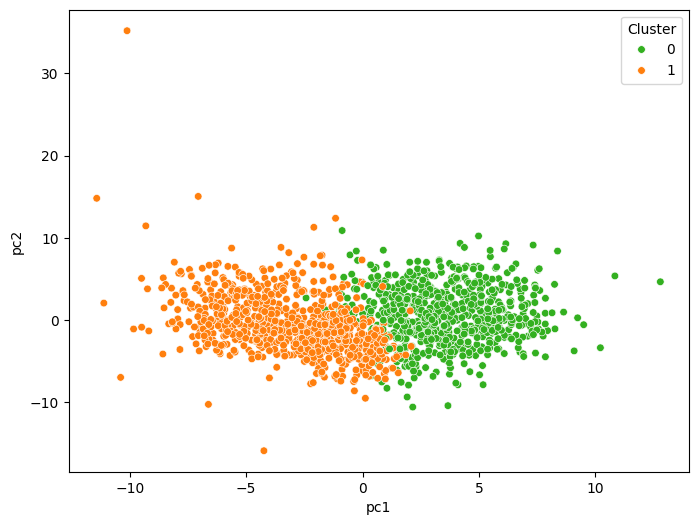

In [41]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette=palette)
plt.show()


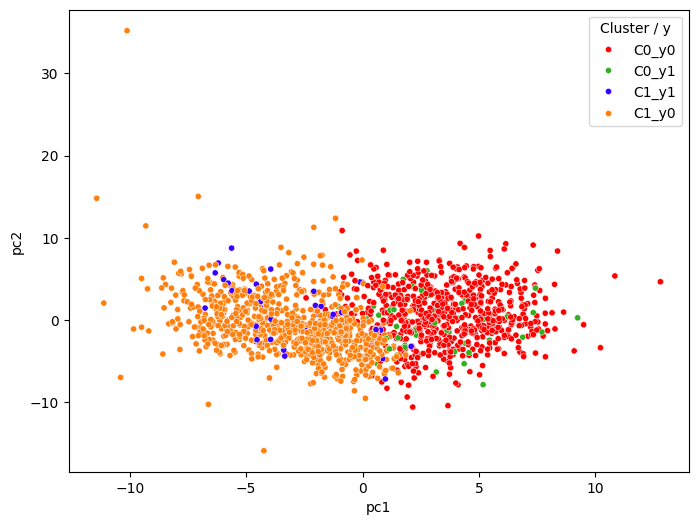

In [42]:
X_pca_df['y'] = y.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['Cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#ff0000",  # cluster 0, y=0
    'C0_y1': "#33B020",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

In [7]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42)
logitR =  LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
clf = logitR.fit(X_train, y_train)
y_pred_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob>0.5).astype(int)

# 8. 套用 B 做法的 local_surrogate（x0 取一個測試點）
x0 = X_test.iloc[1].values   # 設計點 x0，用標準化+SMOTE 後的空間
sur_model, info = local_surrogate(
    x0=x0,
    blackbox_model=clf,
    scaler=None,             # 現在工作空間本身就是標準化後的
    n_samples=1000,
    sigma=0.5,
    surrogate_type="linear", # 或 "tree"
    random_state=42
)

print("local R2 =", info["r2"])
print("local MSE =", info["mse"])
print("coef =", sur_model.coef_)

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
local R2 = 0.6520870715167235
local MSE = 0.01186989047372278
coef = [-2.75173985e-03 -2.74908776e-03 -2.63828550e-03 -5.99241154e-03
  7.13856968e-04 -2.07323914e-02 -9.00782291e-03 -3.33560120e-02
 -3.19903767e-03  9.58292379e-03  9.27750830e-03  1.30126397e-02
  8.42703304e-03 -1.27683919e-02  3.08282063e-03  2.59921399e-02
 -1.39924812e-03 -2.65767808e-03 -2.27900438e-04  4.29995588e-02
 -3.81885562e-02 -1.77975369e-02 -1.03016926e-02  8.90193882e-03
 -1.31744871e-02  7.19574981e-04  5.92755223e-03  2.11854240e-02
  6.93665496e-03  1.09859141e-02 -3.60186717e-03  2.77504245e-02
 -3.82736588e-03  2.23506474e-02  7.77327270e-03  4.98695752e-04
 -2.34088997e-02  3.17278700e-03 -5.54904408e-03  1.40845314e-02
  2.84877370e-02  3.54460518e-03 -1.29804709e-02  2.41589300e-02
 -2.386986

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warni

         local_R2     local_MSE
count  644.000000  6.440000e+02
mean     0.787619  3.132345e-02
std      0.068098  5.368102e-03
min      0.429001  2.049390e-24
25%      0.756572  3.231585e-02
50%      0.816400  3.306738e-02
75%      0.838739  3.370859e-02
max      0.844290  3.543109e-02


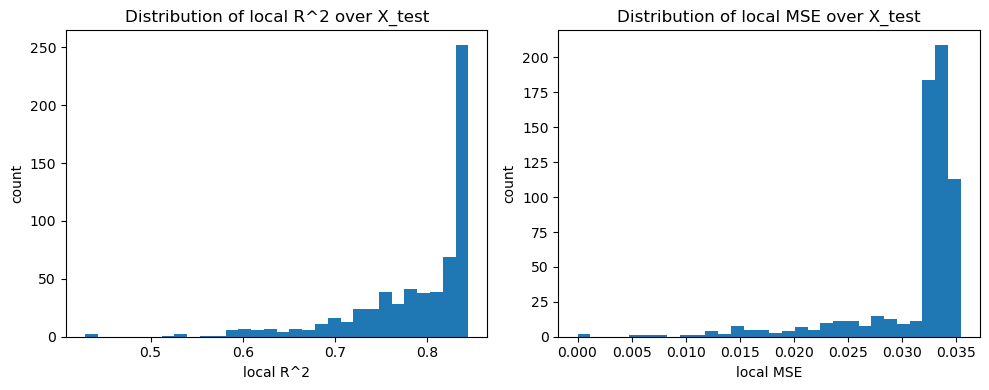

In [14]:
r2_list = []
mse_list = []
for i in range(X_test.shape[0]):
    x0 = X_test.iloc[i].values   # 設計點 x0，用標準化+SMOTE 後的空間
    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,             # 現在工作空間本身就是標準化後的
        n_samples=1000,
        sigma=1,
        surrogate_type="linear", # 或 "tree"
        random_state=42
    )
    r2_list.append(info["r2"])
    mse_list.append(info["mse"])

local_df = pd.DataFrame({
    "local_R2": r2_list,
    "local_MSE": mse_list,
})

print(local_df.describe())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(local_df["local_R2"], bins=30)
plt.xlabel("local R^2")
plt.ylabel("count")
plt.title("Distribution of local R^2 over X_test")

plt.subplot(1,2,2)
plt.hist(local_df["local_MSE"], bins=30)
plt.xlabel("local MSE")
plt.ylabel("count")
plt.title("Distribution of local MSE over X_test")

plt.tight_layout()
plt.show()

### 用LINEAR模型

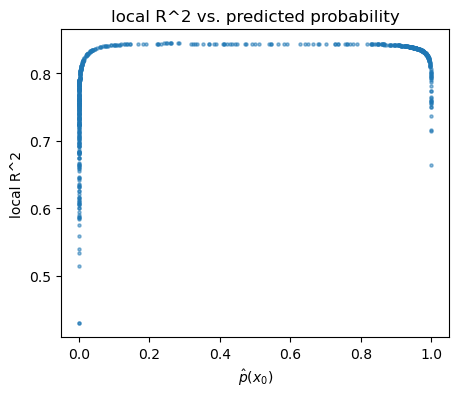

In [15]:
idx = np.arange(len(X_test))
p_test = clf.predict_proba(X_test)[:, 1]

local_df["p_hat"] = p_test[idx]

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability")
plt.show()